In [3]:
import scipy as sp
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, tan, einsum, angle
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator

In [3]:
M = 10000
epsilon = 1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

In [31]:
sigmas_passive_sink = 1j*x*(epsilon*j_ly/yjl_prime-y_lx/xyl_prime)
sigmas_passive_sink_real = sigmas_passive_sink.real
sigmas_passive_sink_imaginary = sigmas_passive_sink.imag
s_s = e_r_cpa(l, x, epsilon, 1j*(sigmas_passive_sink_real + 1j*sigmas_passive_sink_imaginary)/x)

In [98]:
x_idx = 2000; N = 1200
# We sweep from 1/2 to 1.5 times the imaginary conductivity corresponding to the passive sink
sigmas_off_passive_sink = 1j*linspace(1/2, 3/2, N) * sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = e_r_cpa(l, x[x_idx], epsilon, 1j*(sigmas_off_passive_sink)/x[x_idx])

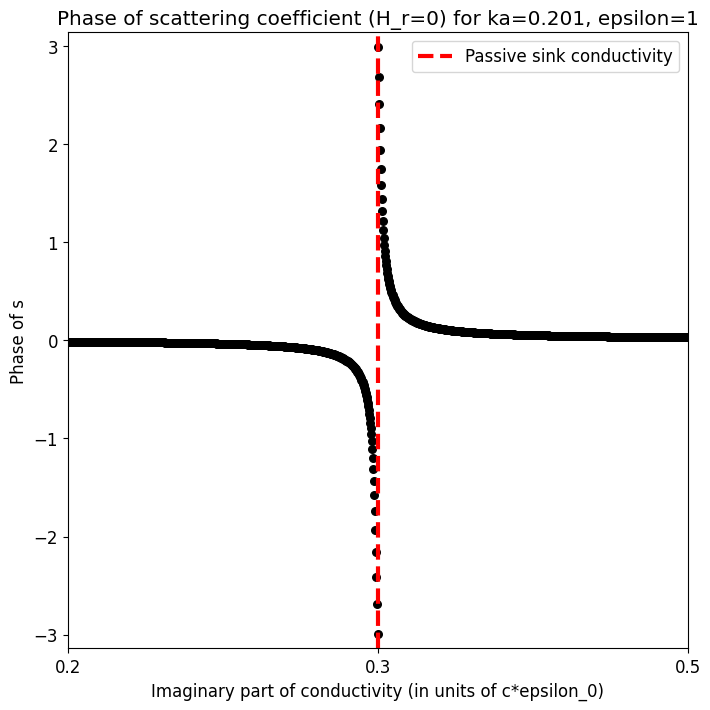

In [100]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(8, 8))
sigmas_off_passive_sink_imag = sigmas_off_passive_sink.imag
min_x = sigmas_off_passive_sink_imag.min()
max_x = sigmas_off_passive_sink_imag.max()
ax.scatter(sigmas_off_passive_sink_imag, angle(s_off_passive_sink), color="black", s=30)
ax.set_xlim(min_x, max_x)
ax.vlines([sigmas_passive_sink_imaginary[x_idx]], -pi, pi, color="red", linestyle="dashed", linewidth=3, label="Passive sink conductivity")
ax.set_ylim(-pi, pi)
ax.set_xlabel("Imaginary part of conductivity (in units of c*epsilon_0)");
ax.set_ylabel("Phase of s");
ax.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 1));
ax.set_title(f"Phase of scattering coefficient (H_r=0) for ka={x[x_idx].round(3)}, epsilon={epsilon}");
ax.legend();


In [115]:
x_idx = 2200
N = 10000
sigmas_off_passive_sink = linspace(0, 0.005, N) + 1j*sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = e_r_cpa(l, x[x_idx], epsilon, 1j*(sigmas_off_passive_sink)/x[x_idx])

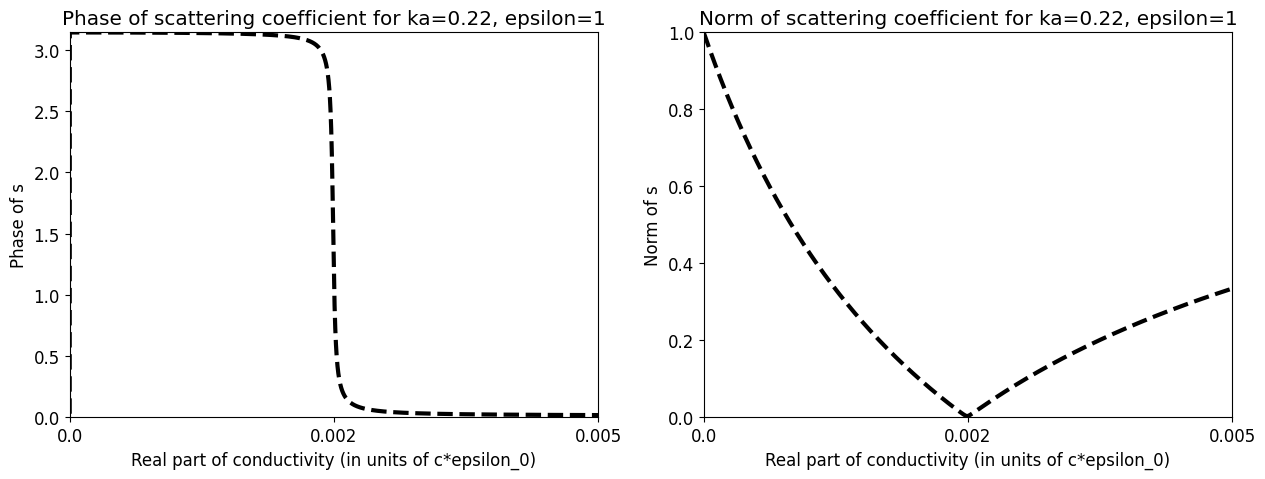

In [116]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sigmas_off_passive_sink_real = sigmas_off_passive_sink.real
min_x = sigmas_off_passive_sink_real.min()
max_x = sigmas_off_passive_sink_real.max()
ax1.plot(sigmas_off_passive_sink_real, angle(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(min_x, max_x)
ax1.set_ylim(0, pi)
ax1.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax1.set_ylabel("Phase of s");
ax1.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax1.set_title(f"Phase of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");

ax2.plot(sigmas_off_passive_sink_real, np.abs(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax2.set_xlim(min_x, max_x)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax2.set_ylabel("Norm of s");
ax2.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax2.set_title(f"Norm of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");


## Magnetic modes ($E_r=0$)

In [24]:
M = 10000
epsilon = 3
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

In [25]:
sigmas_passive_sink = 1j*(1/x)*(xyl_prime/y_lx-yjl_prime/j_ly)
sigmas_passive_sink_real = sigmas_passive_sink.real
sigmas_passive_sink_imaginary = sigmas_passive_sink.imag
s_s = h_r_cpa(l, x, epsilon, 1j*(sigmas_passive_sink_real + 1j*sigmas_passive_sink_imaginary)*x)

In [27]:
x_idx = 1000; N = 1200
# We sweep from 1/2 to 1.5 times the imaginary conductivity corresponding to the passive sink
sigmas_off_passive_sink = 1j*linspace(0.98, 1.02, N) * sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = h_r_cpa(l, x[x_idx], epsilon, 1j*(sigmas_off_passive_sink)*x[x_idx])

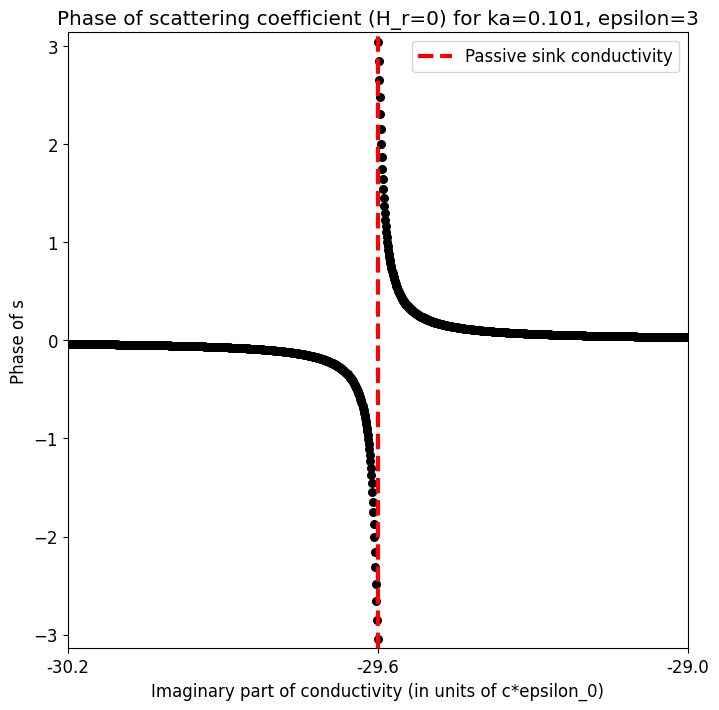

In [28]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(8, 8))
sigmas_off_passive_sink_imag = sigmas_off_passive_sink.imag
min_x = sigmas_off_passive_sink_imag.min()
max_x = sigmas_off_passive_sink_imag.max()
ax.scatter(sigmas_off_passive_sink_imag, angle(s_off_passive_sink), color="black", s=30)
ax.set_xlim(min_x, max_x)
ax.vlines([sigmas_passive_sink_imaginary[x_idx]], -pi, pi, color="red", linestyle="dashed", linewidth=3, label="Passive sink conductivity")
ax.set_ylim(-pi, pi)
ax.set_xlabel("Imaginary part of conductivity (in units of c*epsilon_0)");
ax.set_ylabel("Phase of s");
ax.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 1));
ax.set_title(f"Phase of scattering coefficient (H_r=0) for ka={x[x_idx].round(3)}, epsilon={epsilon}");
ax.legend();

In [33]:
x_idx = 2200
N = 10000
sigmas_off_passive_sink = linspace(0, 0.1, N) + 1j*sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = h_r_cpa(l, x[x_idx], epsilon, 1j*(sigmas_off_passive_sink)*x[x_idx])

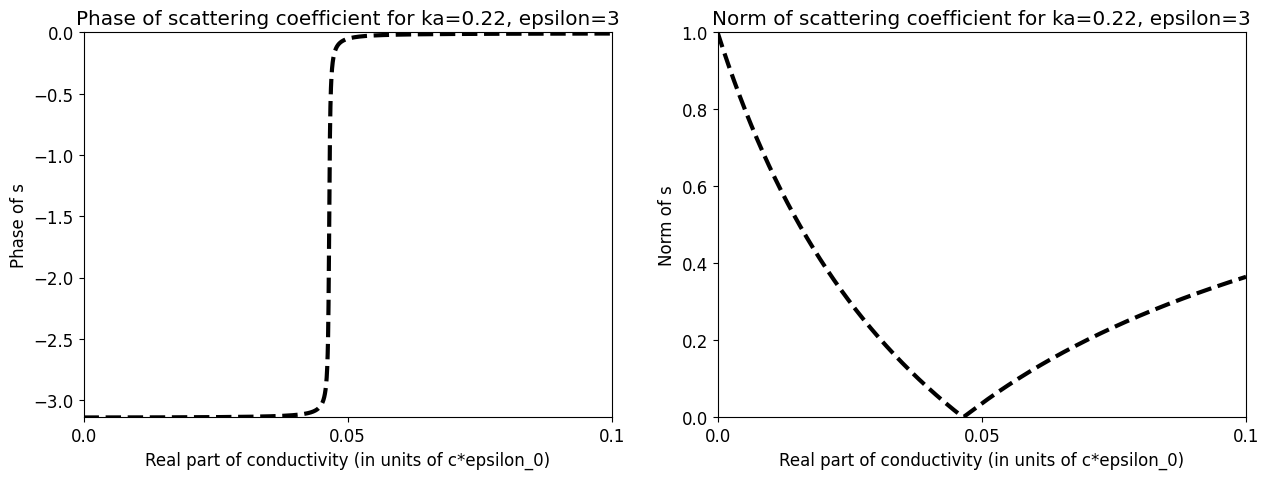

In [35]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sigmas_off_passive_sink_real = sigmas_off_passive_sink.real
min_x = sigmas_off_passive_sink_real.min()
max_x = sigmas_off_passive_sink_real.max()
ax1.plot(sigmas_off_passive_sink_real, angle(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(min_x, max_x)
ax1.set_ylim(-pi, 0)
ax1.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax1.set_ylabel("Phase of s");
ax1.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax1.set_title(f"Phase of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");

ax2.plot(sigmas_off_passive_sink_real, np.abs(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax2.set_xlim(min_x, max_x)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax2.set_ylabel("Norm of s");
ax2.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax2.set_title(f"Norm of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");
